<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%204/TF-IDF/TF-IDF_Artikel_Tribunnews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF (Pasca-Kematian Ali Khamenei — Tribunnews)

## 1. Import Dependencies

In [6]:
!pip install Sastrawi -U

In [9]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd
import math

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Define Document

In [12]:
import requests
from bs4 import BeautifulSoup

url = "https://aceh.tribunnews.com/news/1018596/duka-dan-amarah-di-pemakaman-komandan-al-irgc-warga-iran-bersumpah-melawan-as-sampai-akhir"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Find the main article content based on the provided inspect data
    # The main article text seems to be within div class="side-article txt-article multi-fontsize editcontent"
    article_container = soup.find('div', class_='side-article txt-article multi-fontsize editcontent')

    if article_container:
        # Extract text from all <p> tags within the article container
        paragraphs = article_container.find_all('p')
        article_text = "\n".join([p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True) != ''])

        sentence = article_text
    else:
        sentence = "Error: Could not find article content on the page."
        print(sentence)

except requests.exceptions.RequestException as e:
    sentence = f"Error fetching the URL: {e}"
    print(sentence)


print("Dokumen Berita:")
print(sentence[:300], "...")

Dokumen Berita:
SERAMBINEWS.COM- Ribuan warga memadati jalanan Teheran pada Rabu (1/4), mengiringi pemakaman komandan angkatan laut Garda Revolusi, Alireza Tangsiri, yang tewas dalam serangan Israel.
Di tengah suasana berkabung, gelombang kemarahan dan tekad terlihat jelas para pelayat bersumpah akan terus melawan  ...


## 3. Text Preprocessing

In [13]:
# SENTENCE TOKENIZATION
sent_token = sent_tokenize(sentence)

print("Sentence Tokens:")
for i, s in enumerate(sent_token):
    print(f"{i+1}. {s}")
print(f"\nTotal kalimat: {len(sent_token)}")

Sentence Tokens:
1. SERAMBINEWS.COM- Ribuan warga memadati jalanan Teheran pada Rabu (1/4), mengiringi pemakaman komandan angkatan laut Garda Revolusi, Alireza Tangsiri, yang tewas dalam serangan Israel.
2. Di tengah suasana berkabung, gelombang kemarahan dan tekad terlihat jelas para pelayat bersumpah akan terus melawan meski tekanan militer dari AS dan Israel kian intens.
3. Prosesi pemakaman berlangsung bertepatan dengan peringatan ke-47 berdirinya Republik Islam Iran, yang diproklamasikan pada 1 April 1979 usai Revolusi Iran 1979.
4. •Trump Geram Sekutu Tak Dukung Perang Lawan Iran, Pertimbangkan Tarik AS dari NATO
Namun tahun ini, peringatan tersebut terasa berbeda.
5. Iran kini berada di bawah serangan udara beruntun sejak akhir Februari, menjadikan momen nasional ini sarat emosi dan ketegangan.
6. “Perang ini sudah berlangsung sebulan.
7. Berapa pun lamanya, kami akan terus berjuang,” kata Moussa Nowruzi (57), seorang pensiunan, dengan nada tegas.
8. Di Lapangan Enghelab, lautan

In [14]:
# STOPWORD REMOVAL & CLEANING (menggunakan Sastrawi untuk Bahasa Indonesia)
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

cleaned_sentences = []

for sent in sent_token:
    # Hapus stopword bahasa Indonesia menggunakan Sastrawi
    removed = stopword_remover.remove(sent)
    # Tokenisasi kata, hanya ambil karakter alfabet
    words = word_tokenize(removed.lower())
    filtered_words = [w for w in words if w.isalpha()]
    cleaned_sentences.append(" ".join(filtered_words))

print("Cleaned Sentences (setelah stopword removal Bahasa Indonesia):")
for i, cs in enumerate(cleaned_sentences):
    print(f"{i+1}. {cs}")

Cleaned Sentences (setelah stopword removal Bahasa Indonesia):
1. ribuan warga memadati jalanan teheran rabu mengiringi pemakaman komandan angkatan laut garda revolusi alireza tangsiri tewas serangan israel
2. di tengah suasana berkabung gelombang kemarahan tekad terlihat jelas pelayat bersumpah terus melawan meski tekanan militer as israel kian intens
3. prosesi pemakaman berlangsung bertepatan peringatan berdirinya republik islam iran diproklamasikan april usai revolusi iran
4. geram sekutu tak dukung perang lawan iran pertimbangkan tarik as nato namun tahun ini peringatan tersebut terasa berbeda
5. iran kini berada bawah serangan udara beruntun sejak akhir februari menjadikan momen nasional sarat emosi ketegangan
6. perang sudah berlangsung sebulan
7. berapa lamanya akan terus berjuang kata moussa nowruzi seorang pensiunan nada tegas
8. di lapangan enghelab lautan manusia mengibarkan bendera iran meneriakkan slogan dukungan pemimpin tertinggi
9. spanduk bertuliskan balas dendam dian

## 4. TF-IDF Vectorization

In [15]:
# TRAINING TF-IDF VECTORIZER
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("TF-IDF Feature Matrix")
print(features)

print("\nShape (jumlah kalimat, jumlah kata unik):")
print(features.shape)

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 321 stored elements and shape (26, 254)>
  Coords	Values
  (0, 188)	0.24991593681927035
  (0, 252)	0.22178912013844942
  (0, 115)	0.24991593681927035
  (0, 72)	0.24991593681927035
  (0, 225)	0.22178912013844942
  (0, 183)	0.24991593681927035
  (0, 131)	0.24991593681927035
  (0, 158)	0.2018328261136345
  (0, 94)	0.24991593681927035
  (0, 7)	0.24991593681927035
  (0, 102)	0.24991593681927035
  (0, 57)	0.24991593681927035
  (0, 186)	0.22178912013844942
  (0, 4)	0.24991593681927035
  (0, 221)	0.2018328261136345
  (0, 240)	0.24991593681927035
  (0, 203)	0.18635352188791102
  (0, 71)	0.22178912013844942
  (1, 71)	0.2162796059764599
  (1, 36)	0.15896325457335636
  (1, 228)	0.19681905080701312
  (1, 213)	0.24370771798349913
  (1, 26)	0.24370771798349913
  (1, 58)	0.2162796059764599
  (1, 85)	0.19681905080701312
  :	:
  (23, 82)	0.3442183030990275
  (23, 62)	0.3442183030990275
  (24, 158)	0.18537903203924153
  (

In [16]:
# FEATURE NAMES (VOCABULARY)
feature_names = vectorizer.get_feature_names_out()

print("Vocabulary (Kata Unik Setelah Preprocessing)")
print(feature_names)
print(f"\nTotal kata dalam vocabulary: {len(feature_names)}")

Vocabulary (Kata Unik Setelah Preprocessing)
['akal' 'akan' 'akhir' 'ali' 'alireza' 'amerika' 'ancaman' 'angkatan'
 'apa' 'april' 'arsitek' 'as' 'bahkan' 'balas' 'balik' 'bawah' 'bebas'
 'belum' 'bendera' 'berada' 'berapa' 'berbagai' 'berbeda' 'berdirinya'
 'berharap' 'berjuang' 'berkabung' 'berlangsung' 'berlanjut' 'bersih'
 'bersumpah' 'bertahan' 'bertepatan' 'bertuliskan' 'beruntun' 'dendam'
 'di' 'dia' 'diangkat' 'diarak' 'dibantah' 'dikenal' 'dilaporkan'
 'diproklamasikan' 'disampaikan' 'disebutkan' 'donald' 'drone' 'duka'
 'dukung' 'dukungan' 'dunia' 'emosi' 'energi' 'enggan' 'enghelab'
 'februari' 'garda' 'gelombang' 'gencatan' 'geram' 'hadapan' 'hidupnya'
 'hingga' 'homa' 'hormuz' 'ia' 'ini' 'intens' 'iran' 'islam' 'israel'
 'jalanan' 'janji' 'jelas' 'jenazah' 'juga' 'justru' 'kami' 'kata'
 'katakan' 'kawasan' 'kebebasan' 'kecewa' 'kemampuan' 'kemarahan'
 'kepemimpinan' 'keras' 'kerumunan' 'ketegangan' 'khamenei' 'kian' 'kini'
 'klaim' 'komandan' 'kontroversial' 'kota' 'kuat' '

In [17]:
# TF-IDF KALIMAT PERTAMA
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': tfidf_values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

first_sentence_df = get_tfidf_for_sentence(features, 0, feature_names)

print("TF-IDF Kalimat Pertama (Sorted)")
print(first_sentence_df.to_string(index=False))

TF-IDF Kalimat Pertama (Sorted)
   Feature   TF-IDF
   alireza 0.249916
  angkatan 0.249916
     garda 0.249916
   jalanan 0.249916
  komandan 0.249916
      laut 0.249916
mengiringi 0.249916
  memadati 0.249916
    ribuan 0.249916
      rabu 0.249916
     tewas 0.249916
    israel 0.221789
     warga 0.221789
  revolusi 0.221789
   teheran 0.221789
 pemakaman 0.201833
  tangsiri 0.201833
  serangan 0.186354


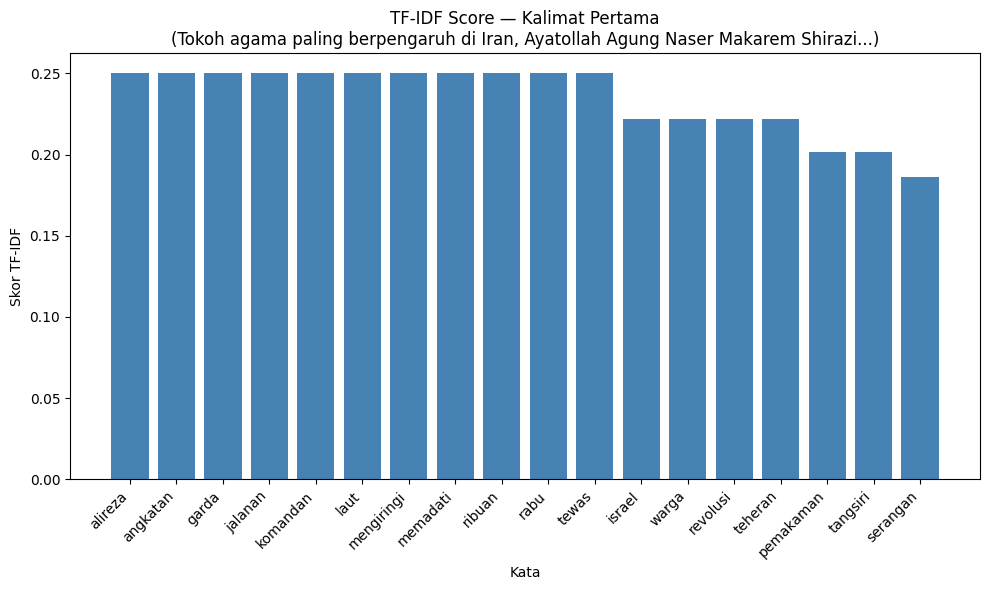

In [18]:
# VISUALISASI TF-IDF KALIMAT PERTAMA
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_df['Feature'], first_sentence_df['TF-IDF'], color='steelblue')
plt.xlabel("Kata")
plt.ylabel("Skor TF-IDF")
plt.title("TF-IDF Score — Kalimat Pertama\n(Tokoh agama paling berpengaruh di Iran, Ayatollah Agung Naser Makarem Shirazi...)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Hitung Sentence Score

In [19]:
# HITUNG RATA-RATA SKOR TF-IDF PER KALIMAT
sent_scores = []

print("Average TF-IDF Score per Kalimat")

for i in range(features.shape[0]):
    row = features[i]
    sum_score  = row.sum()
    word_count = len(row.data)
    avg_score  = sum_score / word_count if word_count > 0 else 0
    sent_scores.append(avg_score)

    print(f"Kalimat {i+1:2d} | Sum: {sum_score:.4f} | Words: {word_count:3d} | Avg: {avg_score:.4f}")

print("\nSemua Sentence Scores:")
print(sent_scores)

Average TF-IDF Score per Kalimat
Kalimat  1 | Sum: 4.2263 | Words:  18 | Avg: 0.2348
Kalimat  2 | Sum: 4.4453 | Words:  20 | Avg: 0.2223
Kalimat  3 | Sum: 3.5966 | Words:  13 | Avg: 0.2767
Kalimat  4 | Sum: 4.2063 | Words:  18 | Avg: 0.2337
Kalimat  5 | Sum: 3.9641 | Words:  16 | Avg: 0.2478
Kalimat  6 | Sum: 1.9923 | Words:   4 | Avg: 0.4981
Kalimat  7 | Sum: 3.4577 | Words:  12 | Avg: 0.2881
Kalimat  8 | Sum: 3.5597 | Words:  13 | Avg: 0.2738
Kalimat  9 | Sum: 3.5954 | Words:  13 | Avg: 0.2766
Kalimat 10 | Sum: 2.6394 | Words:   7 | Avg: 0.3771
Kalimat 11 | Sum: 4.0943 | Words:  17 | Avg: 0.2408
Kalimat 12 | Sum: 3.2868 | Words:  11 | Avg: 0.2988
Kalimat 13 | Sum: 3.2820 | Words:  11 | Avg: 0.2984
Kalimat 14 | Sum: 3.2964 | Words:  11 | Avg: 0.2997
Kalimat 15 | Sum: 2.6378 | Words:   7 | Avg: 0.3768
Kalimat 16 | Sum: 2.8249 | Words:   8 | Avg: 0.3531
Kalimat 17 | Sum: 4.9666 | Words:  25 | Avg: 0.1987
Kalimat 18 | Sum: 4.2058 | Words:  18 | Avg: 0.2337
Kalimat 19 | Sum: 3.1568 | Word

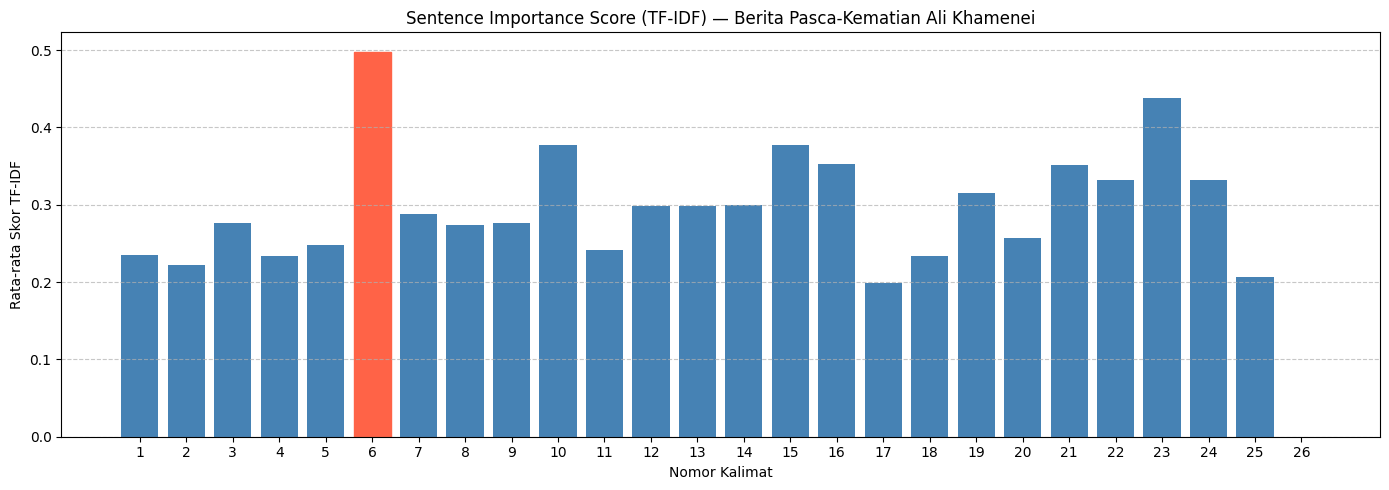


Penjelasan Histogram
Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat.

- Batang merah  → kalimat dengan skor tertinggi (paling informatif).
- Batang tinggi → kalimat mengandung kata spesifik & jarang muncul → kandidat kuat untuk ringkasan.
- Batang rendah → kalimat didominasi kata umum / informasi pendukung.


In [20]:
# VISUALISASI SENTENCE SCORE
plt.figure(figsize=(14, 5))
bars = plt.bar(range(1, len(sent_scores)+1), sent_scores, color='steelblue')

# Highlight bar tertinggi
max_idx = sent_scores.index(max(sent_scores))
bars[max_idx].set_color('tomato')

plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Sentence Importance Score (TF-IDF) — Berita Pasca-Kematian Ali Khamenei")
plt.xticks(range(1, len(sent_scores)+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nPenjelasan Histogram")
print(
    "Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan "
    "metode TF-IDF (Term Frequency\u2013Inverse Document Frequency). "
    "Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat."
)
print(
    "\n- Batang merah  \u2192 kalimat dengan skor tertinggi (paling informatif)."
)
print(
    "- Batang tinggi \u2192 kalimat mengandung kata spesifik & jarang muncul \u2192 kandidat kuat untuk ringkasan."
)
print(
    "- Batang rendah \u2192 kalimat didominasi kata umum / informasi pendukung."
)

## 6. Define Threshold

In [21]:
# THRESHOLD = RATA-RATA SEMUA SENTENCE SCORES
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold")
print(f"Threshold (Rata-rata Sentence Score): {threshold:.6f}")
print(f"\nKalimat yang skornya >= {threshold:.4f} akan masuk ke ringkasan.")

Threshold
Threshold (Rata-rata Sentence Score): 0.286964

Kalimat yang skornya >= 0.2870 akan masuk ke ringkasan.


In [22]:
# CONTOH MANUAL: TF-IDF KATA 'iran' PER KALIMAT

cleaned_lower = [s.lower() for s in sent_token]

def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if words else 0

def calculate_idf(term, documents):
    doc_count = sum(1 for doc in documents if term in word_tokenize(doc))
    return math.log(len(documents) / doc_count) if doc_count > 0 else 0

term = "iran"
idf_value = calculate_idf(term, cleaned_lower)
tfidf_per_sent = {}

for i, doc in enumerate(cleaned_lower):
    tf = calculate_tf(term, doc)
    tfidf_per_sent[f"Kalimat {i+1}"] = tf * idf_value

print(f"TF-IDF Manual untuk kata '{term}'")
for k, v in tfidf_per_sent.items():
    print(f"{k}: {v:.4f}")
print(f"\nIDF('{term}'): {idf_value:.4f}")

TF-IDF Manual untuk kata 'iran'
Kalimat 1: 0.0000
Kalimat 2: 0.0000
Kalimat 3: 0.0831
Kalimat 4: 0.0415
Kalimat 5: 0.0455
Kalimat 6: 0.0000
Kalimat 7: 0.0000
Kalimat 8: 0.0562
Kalimat 9: 0.0000
Kalimat 10: 0.0000
Kalimat 11: 0.0434
Kalimat 12: 0.0000
Kalimat 13: 0.0597
Kalimat 14: 0.0000
Kalimat 15: 0.0000
Kalimat 16: 0.0000
Kalimat 17: 0.0251
Kalimat 18: 0.0434
Kalimat 19: 0.0000
Kalimat 20: 0.0000
Kalimat 21: 0.0000
Kalimat 22: 0.0000
Kalimat 23: 0.1062
Kalimat 24: 0.0000
Kalimat 25: 0.0281
Kalimat 26: 0.0000

IDF('iran'): 0.9555


## 7. Generate Summary

In [23]:
# AMBIL KALIMAT DI ATAS THRESHOLD
final_summ = ""

print(f"Threshold: {threshold:.4f}")
print("\nKalimat yang Masuk Ringkasan")

for index, score in enumerate(sent_scores):
    if score >= threshold:
        final_summ += " " + sent_token[index]
        print(f"[{index+1}] (skor={score:.4f}) {sent_token[index]}")

print("\n" + "="*60)
print("HASIL RINGKASAN AKHIR")
print("="*60)
print(final_summ.strip())

Threshold: 0.2870

Kalimat yang Masuk Ringkasan
[6] (skor=0.4981) “Perang ini sudah berlangsung sebulan.
[7] (skor=0.2881) Berapa pun lamanya, kami akan terus berjuang,” kata Moussa Nowruzi (57), seorang pensiunan, dengan nada tegas.
[10] (skor=0.3771) Peti jenazah Tangsiri diarak perlahan melewati kerumunan.
[12] (skor=0.2988) Di tengah situasi yang memanas, Presiden AS Donald Trump kembali melontarkan pernyataan kontroversial.
[13] (skor=0.2984) Ia mengklaim Iran telah meminta gencatan senjata, namun klaim tersebut dibantah keras oleh Teheran.
[14] (skor=0.2997) Trump juga menegaskan bahwa serangan akan terus berlanjut hingga Selat Hormuz “terbuka, bebas, dan bersih”.
[15] (skor=0.3768) Namun ancaman itu tampaknya tak menggoyahkan semangat warga.
[16] (skor=0.3531) “Kami tidak peduli dengan apa yang dia katakan,” ujar Homa Vosoogh (36).
[19] (skor=0.3157) Negara itu juga masih memiliki kemampuan meluncurkan rudal dan drone ke berbagai target di kawasan.
[21] (skor=0.3509) Di balik ge

## 8. Summarization Result

In [24]:
# TAMPILKAN RINGKASAN FINAL
print("RINGKASAN BERITA PASCA-KEMATIAN ALI KHAMENEI")
print(final_summ.strip())

RINGKASAN BERITA PASCA-KEMATIAN ALI KHAMENEI
“Perang ini sudah berlangsung sebulan. Berapa pun lamanya, kami akan terus berjuang,” kata Moussa Nowruzi (57), seorang pensiunan, dengan nada tegas. Peti jenazah Tangsiri diarak perlahan melewati kerumunan. Di tengah situasi yang memanas, Presiden AS Donald Trump kembali melontarkan pernyataan kontroversial. Ia mengklaim Iran telah meminta gencatan senjata, namun klaim tersebut dibantah keras oleh Teheran. Trump juga menegaskan bahwa serangan akan terus berlanjut hingga Selat Hormuz “terbuka, bebas, dan bersih”. Namun ancaman itu tampaknya tak menggoyahkan semangat warga. “Kami tidak peduli dengan apa yang dia katakan,” ujar Homa Vosoogh (36). Negara itu juga masih memiliki kemampuan meluncurkan rudal dan drone ke berbagai target di kawasan. Di balik gelombang solidaritas, terselip suara-suara lirih yang mendambakan perubahan. Seorang wanita yang enggan disebutkan namanya mengaku kecewa terhadap janji Trump. “Dia mengkhianati rakyat Iran,” 